In [1]:
import ast
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import HTML, Video, display
from matplotlib import cm


In [2]:
def load_trajectories(txt_path):
    trajectories = {}

    with open(txt_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            id_part, points_part = line.split(":", 1)
            obj_id = int(id_part.replace("ID", "").strip())
            points = ast.literal_eval(points_part.strip())
            trajectories[obj_id] = points

    return trajectories


def natural_key(path):
    import re

    parts = re.split(r"(\d+)", path.name)
    return [int(part) if part.isdigit() else part.lower() for part in parts]


def load_image_paths(folder):
    folder = Path(folder)
    image_paths = []
    for pattern in ("*.jpg", "*.jpeg", "*.png"):
        image_paths.extend(folder.glob(pattern))
    return sorted(image_paths, key=natural_key)


def interpolate_points(points, max_gap=8):
    points = sorted(points, key=lambda item: item[0])
    if not points:
        return {}

    interpolated = {frame_idx: (x, y) for frame_idx, x, y in points}
    for (frame_a, x_a, y_a), (frame_b, x_b, y_b) in zip(points, points[1:]):
        gap = frame_b - frame_a
        if gap <= 1 or gap > max_gap:
            continue

        for step in range(1, gap):
            alpha = step / gap
            x = int(round(x_a + alpha * (x_b - x_a)))
            y = int(round(y_a + alpha * (y_b - y_a)))
            interpolated[frame_a + step] = (x, y)

    return dict(sorted(interpolated.items()))


def build_interpolated_trajectories(trajectories, max_gap=8):
    return {track_id: interpolate_points(points, max_gap=max_gap) for track_id, points in trajectories.items()}


def stable_color(track_id):
    rng = np.random.default_rng(track_id * 9973)
    color = rng.integers(80, 255, size=3)
    return int(color[0]), int(color[1]), int(color[2])


In [ ]:
from config import MODEL_NAME

TRACK_NUMBER = "276"
BASE_PATH = Path(f"runs/detect/track/track_{MODEL_NAME}_{TRACK_NUMBER}")
TRAJ_FILE = BASE_PATH / "trajectories.txt"
REFERENCE_FILE = BASE_PATH / "reference_frame.txt"
FRAME_DIR = BASE_PATH / "frames"
STABILIZED_DIR = BASE_PATH / "stabilized_frames"
VIDEO_FILE = BASE_PATH / "tracking_sequence.mp4"
VIS_DIR = BASE_PATH / "visualizations"

trajectories = load_trajectories(TRAJ_FILE)
interpolated_trajectories = build_interpolated_trajectories(trajectories, max_gap=8)
reference_name = REFERENCE_FILE.read_text(encoding="utf-8").strip() if REFERENCE_FILE.exists() else "00031.jpg"
image_paths = load_image_paths(STABILIZED_DIR)
if not image_paths:
    image_paths = load_image_paths(FRAME_DIR)

VIS_DIR.mkdir(parents=True, exist_ok=True)


In [ ]:
def color_for_track(track_id):
    return stable_color(track_id)


def draw_text_box(img, text, origin, color):
    x, y = origin
    (tw, th), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
    x0 = max(0, x)
    y0 = max(0, y - th - baseline - 8)
    x1 = min(img.shape[1] - 1, x0 + tw + 10)
    y1 = min(img.shape[0] - 1, y0 + th + baseline + 8)
    cv2.rectangle(img, (x0, y0), (x1, y1), (15, 15, 15), -1)
    cv2.rectangle(img, (x0, y0), (x1, y1), color, 1)
    cv2.putText(img, text, (x0 + 5, y1 - baseline - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)


def overlay_trajectories(image, trajectories, frame_idx, trail_len=45):
    overlay = image.copy()
    active_ids = []

    for track_id, track_points in trajectories.items():
        visible_frames = [frame for frame in track_points if frame <= frame_idx]
        if not visible_frames:
            continue

        active_ids.append(track_id)
        tail_frames = visible_frames[-trail_len:]
        tail_points = [track_points[frame] for frame in tail_frames]
        color = color_for_track(track_id)

        for point_index in range(1, len(tail_points)):
            x1, y1 = tail_points[point_index - 1]
            x2, y2 = tail_points[point_index]
            fade = 0.3 + 0.7 * (point_index / max(1, len(tail_points) - 1))
            line_color = tuple(int(channel * fade) for channel in color)
            cv2.line(overlay, (x1, y1), (x2, y2), line_color, 3, cv2.LINE_AA)

        x, y = tail_points[-1]
        cv2.circle(overlay, (x, y), 6, color, -1, cv2.LINE_AA)
        cv2.circle(overlay, (x, y), 11, color, 1, cv2.LINE_AA)
        draw_text_box(overlay, f"ID {track_id}", (x + 10, y - 10), color)

    result = cv2.addWeighted(overlay, 0.9, image, 0.1, 0)
    cv2.rectangle(result, (16, 16), (370, 94), (10, 10, 10), -1)
    cv2.putText(result, f"Frame {frame_idx + 1:04d} / {len(image_paths):04d}", (28, 42), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
    cv2.putText(result, f"Active IDs: {len(active_ids)}", (28, 68), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (220, 220, 220), 1, cv2.LINE_AA)
    return result


def read_frame_by_name(folder, frame_name):
    folder = Path(folder)
    for candidate in folder.glob(frame_name):
        img = cv2.imread(str(candidate))
        if img is not None:
            return img
    return None


In [5]:
def create_contact_sheet(frame_paths, cols=4, max_items=12):
    chosen = list(frame_paths[:max_items])
    if not chosen:
        return None

    rows = int(np.ceil(len(chosen) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows))
    axes = np.atleast_1d(axes).ravel()

    for axis in axes[len(chosen):]:
        axis.axis("off")

    for axis, frame_path in zip(axes, chosen):
        img = cv2.imread(str(frame_path))
        if img is None:
            axis.axis("off")
            continue
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axis.imshow(rgb)
        axis.set_title(frame_path.stem, fontsize=9)
        axis.axis("off")

    fig.tight_layout()
    return fig


def plot_trajectories_on_canvas(trajectories):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_facecolor("#0c0f14")

    for track_id, points in trajectories.items():
        color = np.array(color_for_track(track_id)) / 255.0
        xs = [p[1] for p in points]
        ys = [p[2] for p in points]
        ax.plot(xs, ys, color=color, linewidth=2.5, alpha=0.9)
        ax.scatter(xs[0], ys[0], s=60, color=color, edgecolor="white", linewidth=0.8, zorder=3)
        ax.scatter(xs[-1], ys[-1], s=90, color=color, marker="x", linewidths=2, zorder=3)
        ax.text(xs[-1] + 6, ys[-1] - 6, f"ID {track_id}", color=color, fontsize=9, weight="bold")

    ax.invert_yaxis()
    ax.set_title("Track overview", fontsize=14, weight="bold")
    ax.grid(alpha=0.15)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.tight_layout()
    return fig


def plot_heatmap(trajectories, image_shape):
    heatmap = np.zeros(image_shape[:2], dtype=np.float32)

    for points in trajectories.values():
        for _, x, y in points:
            if 0 <= x < heatmap.shape[1] and 0 <= y < heatmap.shape[0]:
                heatmap[y, x] += 1

    heatmap = cv2.GaussianBlur(heatmap, (0, 0), sigmaX=12, sigmaY=12)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(heatmap, cmap="inferno")
    ax.set_title("Movement density", fontsize=14, weight="bold")
    ax.axis("off")
    fig.tight_layout()
    return fig


In [6]:
def write_video_from_frames(frame_paths, output_path, fps=12):
    if not frame_paths:
        return None

    first_frame = cv2.imread(str(frame_paths[0]))
    if first_frame is None:
        return None

    height, width = first_frame.shape[:2]
    writer = cv2.VideoWriter(
        str(output_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height),
    )

    try:
        for frame_path in frame_paths:
            frame = cv2.imread(str(frame_path))
            if frame is not None:
                writer.write(frame)
    finally:
        writer.release()

    return output_path


def render_tracking_sequence(image_paths, trajectories, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    rendered = []
    for frame_idx, img_path in enumerate(image_paths):
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        frame = overlay_trajectories(img, trajectories, frame_idx)
        out_path = output_dir / f"{frame_idx:05d}.jpg"
        cv2.imwrite(str(out_path), frame)
        rendered.append(out_path)

    return rendered


rendered_dir = VIS_DIR / "sequence_frames"
rendered_frames = render_tracking_sequence(image_paths, interpolated_trajectories, rendered_dir)
video_path = write_video_from_frames(rendered_frames, VIS_DIR / "tracking_preview.mp4", fps=12)


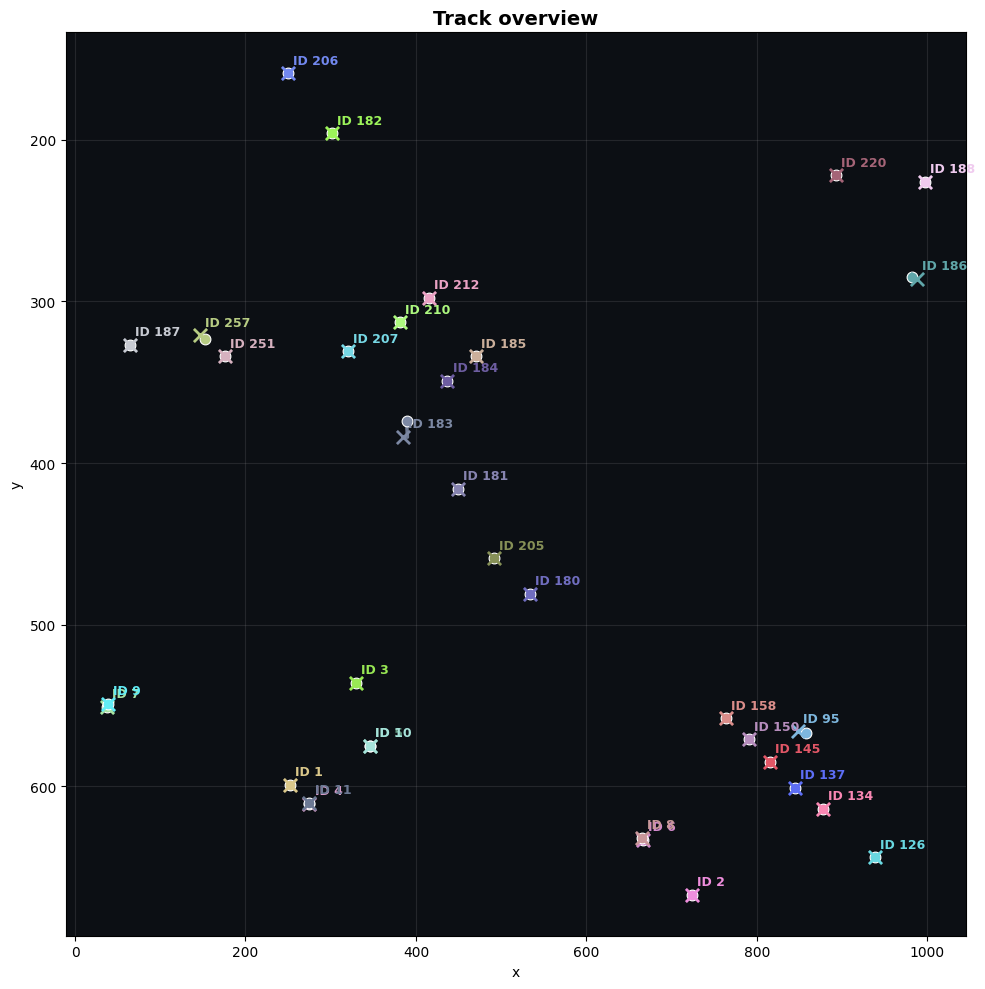

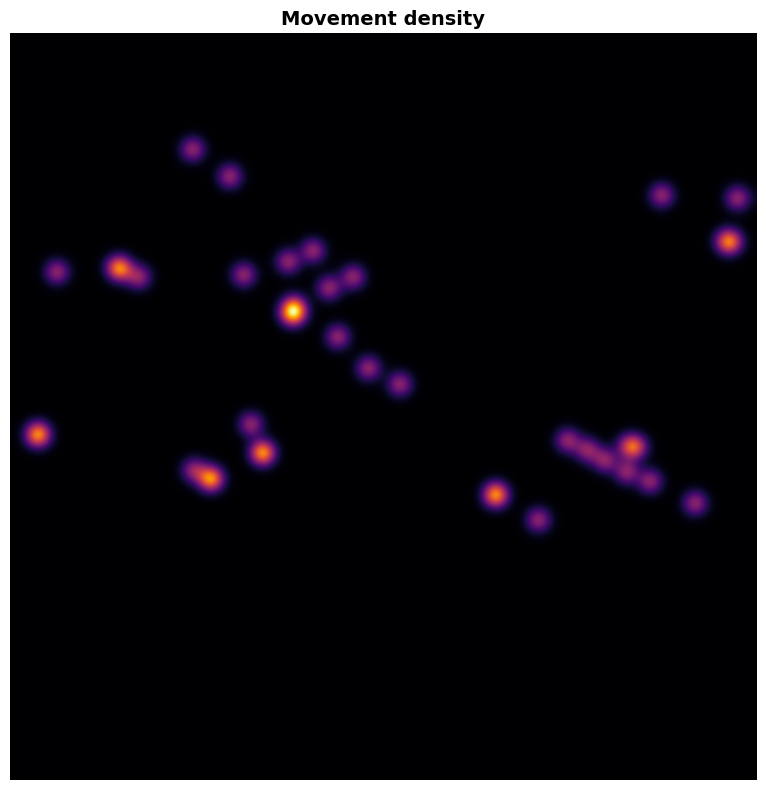

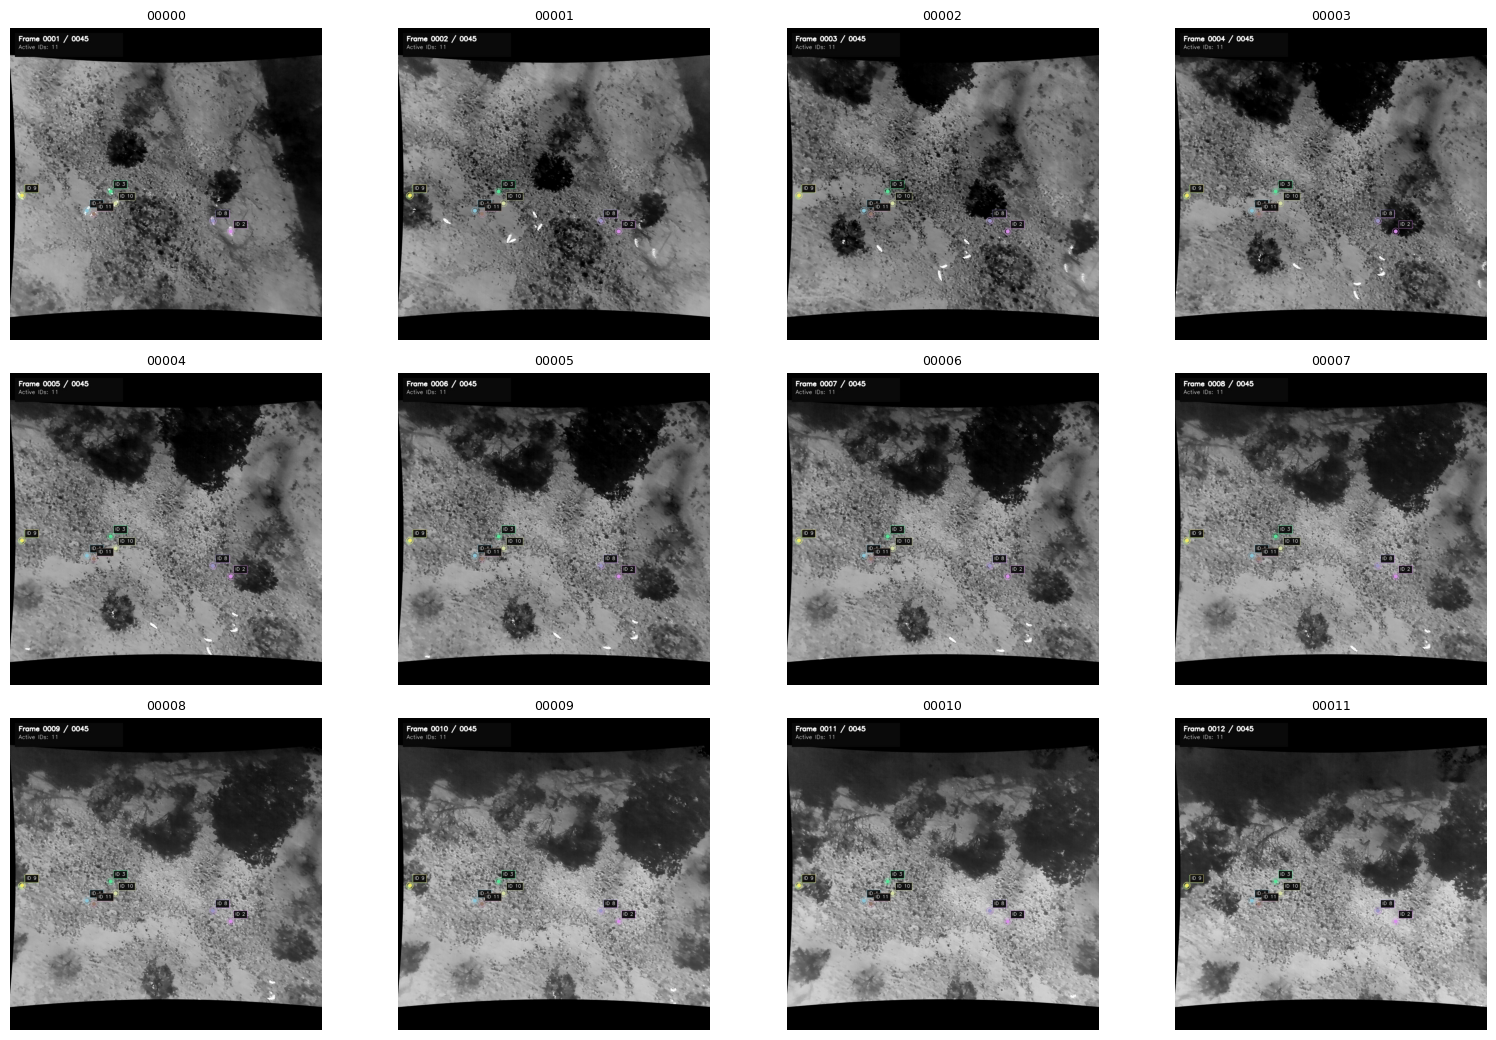

In [ ]:
sample_image = cv2.imread(str(image_paths[0])) if image_paths else None
if sample_image is None:
    raise FileNotFoundError("No frames available for visualization")

reference_frame = read_frame_by_name(STABILIZED_DIR, reference_name)
if reference_frame is None:
    reference_frame = sample_image

reference_rgb = cv2.cvtColor(reference_frame, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 6))
plt.imshow(reference_rgb)
plt.title(f"Reference frame: {reference_name}")
plt.axis("off")
plt.show()

traj_fig = plot_trajectories_on_canvas(trajectories)
plt.show()

heatmap_fig = plot_heatmap(trajectories, sample_image.shape)
plt.show()

sheet = create_contact_sheet(rendered_frames, cols=4, max_items=12)
if sheet is not None:
    plt.show()

if video_path is not None:
    display(HTML(f'<video controls autoplay loop muted style="max-width: 100%; height: auto;" src="{video_path.as_posix()}"></video>'))

if rendered_frames:
    display(Video(str(video_path), embed=True, width=1100))

stabilized_sample = image_paths[0] if image_paths else None
if stabilized_sample is not None:
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(cv2.imread(str(stabilized_sample)), cv2.COLOR_BGR2RGB))
    plt.title("First stabilized frame in sequence")
    plt.axis("off")
    plt.show()


In [ ]:
print(f"Loaded {len(trajectories)} tracks")
print(f"Reference frame: {reference_name}")
print(f"Rendered {len(rendered_frames)} frames")
if video_path is not None:
    print(f"Video saved to: {video_path}")


Loaded 35 tracks
Rendered 45 frames
Video saved to: runs\detect\track\track_yolo26l_annotated_276\visualizations\tracking_preview.mp4
